In [3]:
import os
import random
drive_path = '/Users/samyiin/Projects/ZipfLawAnalysis'
os.chdir(drive_path)

In [4]:
# @title Github Down Stream Tasks
from joblib import Memory
from Utils.GithubAPI import GithubRequestMachine, RateLimitError
from Utils.Secrete import SecreteLoader

# Work around for joblib caching in jupyter notebook "joblib persistence across sessions/machines"
def cache(mem, module, **mem_kwargs):
    # model is the notebook/python file name: Jupyter notebook's name is always changing so we need this work around
    def cache_(f):
        f.__module__ = module
        f.__qualname__ = f.__name__
        return mem.cache(f, **mem_kwargs)

    # return the cache function that will always create same name for cache directory
    return cache_


# Create a memory object with a cache directory
memory = Memory(location="FunctionCache", verbose=0)


GITHUB_FINE_GRAINED_ACCESS_TOKEN = SecreteLoader().get_github_apikey('Bakri')
github_request_machine = GithubRequestMachine(GITHUB_FINE_GRAINED_ACCESS_TOKEN)
# this is a function, the name of function must be "search_endpoint"
search_endpoint = github_request_machine.search_endpoint

@cache(memory, 'search_result_total_count')
def search_result_total_count(target_type, dic_constraints):
    res = search_endpoint(target_type, dic_constraints, page_num=1)
    return res['total_count']

There are certain criterias that is fixed

    type:user language:Python
Also: Native speaker, Not Bot,
There are several criteria we need to decide

    created:<x followers:<x repos:>x

In [16]:
# @title Plot functions
import matplotlib.pyplot as plt

def culmulative_distribution(x, y, legend, x_label, y_label, title, x_log_scale=True, x_axis_reverse=False, y_log_scale=False):
    # Create a step plot
    plt.figure(figsize=(10, 6))
    # where='post' parameter, meaning the step change happens after the point.
    plt.step(x, y, where='post', label=legend, color='blue')
    # Fill the area under the curve
    plt.fill_between(x, y, step='post', color='lightblue', alpha=0.5)

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True)
    plt.legend()
    if x_log_scale:
        plt.xscale('log')  # Use a logarithmic scale for better visualization
    if x_axis_reverse:
        plt.gca().invert_xaxis()
    if y_log_scale:
        plt.yscale('log')  # Use a logarithmic scale for better visualization
    
    # save the pictue
    plt.savefig("Database/ThesisPictures/GithubGatherData_SelectThreshold_CreationDate.pdf", format="pdf", bbox_inches="tight")
    plt.show()

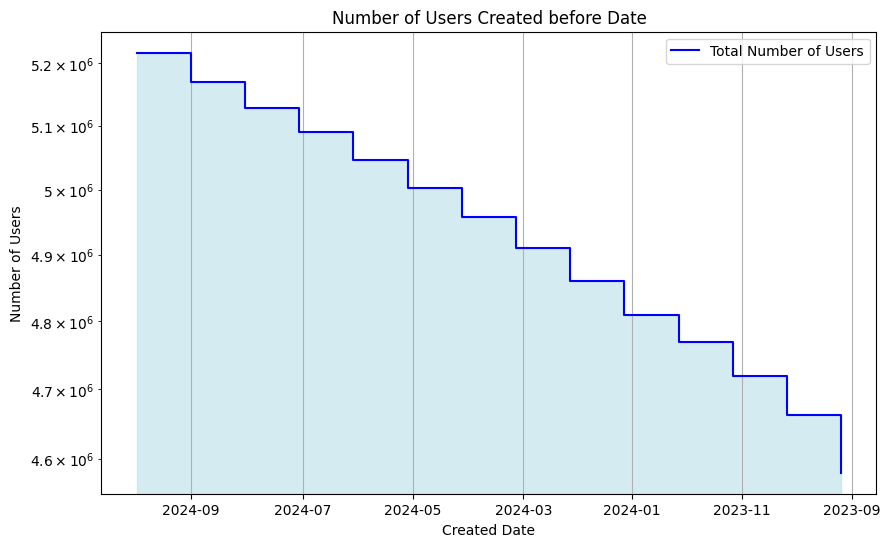

In [18]:
# @title time of creation
from datetime import datetime, timedelta

dic_user_constraints = {"type": 'user', "language": 'Python'}
list_created_before_date = []
number_of_users = []



# Function to get the date string from the number of days before the reference date
def get_date_string(days_before, return_string=True):
    # Reference date
    reference_date = datetime(2024, 10, 1)
    calculated_date = reference_date - timedelta(days=days_before)
    if return_string:
        return calculated_date.strftime('%Y-%m-%d')
    else:
        return calculated_date

thresholds = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390]
for num_days in thresholds:
    create_before_date = get_date_string(num_days)
    dic_user_constraints['created'] = '<=' + create_before_date
    result_total_count = search_result_total_count(target_type='users', dic_constraints=dic_user_constraints)
    list_created_before_date.append(get_date_string(num_days, return_string=False))
    number_of_users.append(result_total_count)


culmulative_distribution(x=list_created_before_date,
                         y=number_of_users,
                         legend="Total Number of Users",
                         x_label="Created Date",
                         y_label="Number of Users",
                         title="Number of Users Created before Date",
                         x_log_scale=False,
                         y_log_scale=True,
                         x_axis_reverse=True)

In [7]:
list_created_before_date

[datetime.datetime(2024, 10, 1, 0, 0),
 datetime.datetime(2024, 9, 1, 0, 0),
 datetime.datetime(2024, 8, 2, 0, 0),
 datetime.datetime(2024, 7, 3, 0, 0),
 datetime.datetime(2024, 6, 3, 0, 0),
 datetime.datetime(2024, 5, 4, 0, 0),
 datetime.datetime(2024, 4, 4, 0, 0),
 datetime.datetime(2024, 3, 5, 0, 0),
 datetime.datetime(2024, 2, 4, 0, 0),
 datetime.datetime(2024, 1, 5, 0, 0),
 datetime.datetime(2023, 12, 6, 0, 0),
 datetime.datetime(2023, 11, 6, 0, 0),
 datetime.datetime(2023, 10, 7, 0, 0),
 datetime.datetime(2023, 9, 7, 0, 0)]

## Repos X Followers
Fix creation time 2024-04-01, let's see how the user number correlates to number of repos and number of followers.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time

def calculate_number_of_users(followers, repos):
    dic_user_constraints = {"type": 'user', "language": 'Python', 'created': '<2024-04-01'}
    dic_user_constraints['repos'] = f'>={repos}'
    dic_user_constraints['followers'] = f'>={followers}'
    try:
        number_filtered_users = search_result_total_count(target_type='users', dic_constraints=dic_user_constraints)
    except RateLimitError as e:
        print(f"Hit the limit!, sleep for {e.wait_time} seconds...")
        # sleep for rate limit to come back
        time.sleep(e.wait_time + 5)
        # try again: This guarantee to work
        number_filtered_users = search_result_total_count(target_type='users', dic_constraints=dic_user_constraints)
    return number_filtered_users


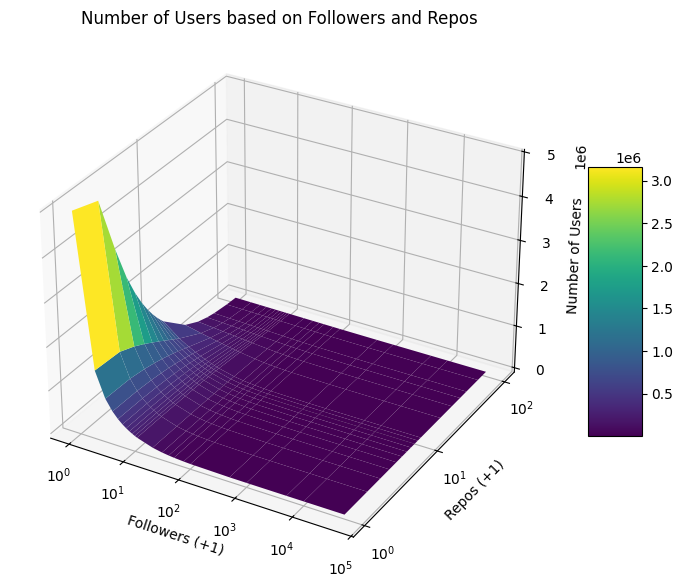

In [19]:
# print the 3d graph
# create a grid
follower_thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 75, 100, 500, 1000, 5000, 10000, 50000]
repo_thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 75, 100]
number_of_users_grid = np.zeros((len(follower_thresholds), len(repo_thresholds)))
for i, followers in enumerate(follower_thresholds):
    for j, repos in enumerate(repo_thresholds):
        number_of_users_grid[i, j] = calculate_number_of_users(followers, repos)
        
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot a surface plot: If we use log scale, we need to start from 1
follower_thresholds_for_plot = [thres + 1 for thres in follower_thresholds]
repo_thresholds_for_plot = [thres + 1 for thres in repo_thresholds]

followers_grid, repos_grid = np.meshgrid(follower_thresholds_for_plot, repo_thresholds_for_plot)
number_of_users_grid = number_of_users_grid.T

# Setting to log scale: This is an on going issue for matplotlib, there is an work around, check this out:
# https://stackoverflow.com/questions/3909794/plotting-mplot3d-axes3d-xyz-surface-plot-with-log-scale
import matplotlib.ticker as mticker
# My axis should display 10⁻¹ but you can switch to e-notation 1.00e+01
def log_tick_formatter(val, pos=None):
    return f"$10^{{{int(val)}}}$"  # remove int() if you don't use MaxNLocator
    # return f"{10**val:.2e}"      # e-Notation

ax.yaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
# important: this step is also crutial
log_followers_grid = np.log10(followers_grid)
log_repos_grid = np.log10(repos_grid)
surf = ax.plot_surface(log_followers_grid, log_repos_grid, number_of_users_grid, cmap='viridis')


# Labels and title
ax.set_xlabel('Followers (+1)')
ax.set_ylabel('Repos (+1)')
ax.set_zlabel('Number of Users')
ax.set_title('Number of Users based on Followers and Repos')

# Add color bar to show the scale of number of users
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.savefig("Database/ThesisPictures/GithubGatherData_SelectThreshold_followerXrepoBefore.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [10]:
# @title Final Decision
# Assume population is Followers >= 1, repos >=1
dic_user_constraints = {"type": 'user', "language": 'Python', 'created': '<2024-04-01'}
huge_population = search_result_total_count(target_type='users', dic_constraints=dic_user_constraints)

dic_user_constraints = {"type": 'user', "language": 'Python', 'created': '<2024-04-01',
                        'repos':">=1", "followers": ">=1"}
total_population = search_result_total_count(target_type='users', dic_constraints=dic_user_constraints)

print(f"Total Population: {total_population}")
print(f"Huge Population: {huge_population}")

Total Population: 1450924
Huge Population: 4951292


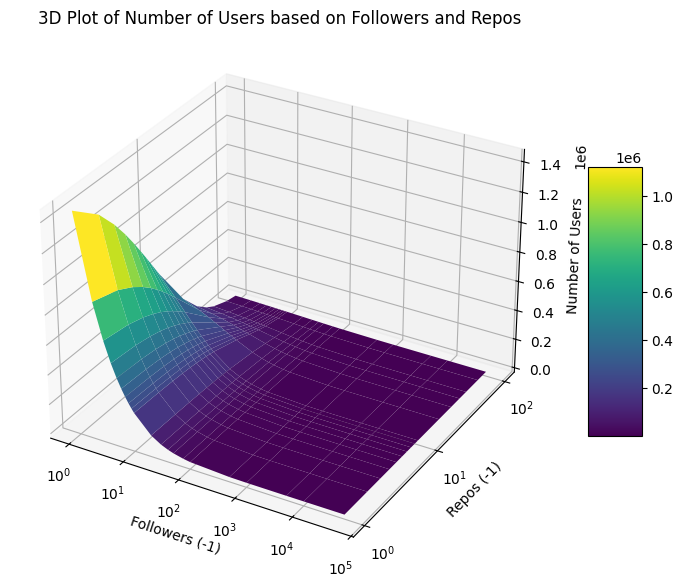

In [11]:
# another graph, without Repo and followers == 0

# create a grid
follower_thresholds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 75, 100, 500, 1000, 5000, 10000, 50000]
repo_thresholds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 75, 100]
number_of_users_grid = np.zeros((len(follower_thresholds), len(repo_thresholds)))
for i, followers in enumerate(follower_thresholds):
    for j, repos in enumerate(repo_thresholds):
        number_of_users_grid[i, j] = calculate_number_of_users(followers, repos)
followers_grid, repos_grid = np.meshgrid(follower_thresholds, repo_thresholds)
number_of_users_grid = number_of_users_grid.T


# print the 3d graph
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
# important: this step is also crutial
log_followers_grid = np.log10(followers_grid)
log_repos_grid = np.log10(repos_grid)
surf = ax.plot_surface(log_followers_grid, log_repos_grid, number_of_users_grid, cmap='viridis')


# Labels and title
ax.set_xlabel('Followers (+1)')
ax.set_ylabel('Repos (+1)')
ax.set_zlabel('Number of Users')
ax.set_title('Number of Users based on Followers and Repos')

# Add color bar to show the scale of number of users
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

/var/folders/2q/npr5yhgs2_553xj46qkrcsdh0000gn/T/ipykernel_69425/2714275274.py:24: RuntimeWarning: divide by zero encountered in log10
  log_followers_grid = np.log10(followers_grid)
/var/folders/2q/npr5yhgs2_553xj46qkrcsdh0000gn/T/ipykernel_69425/2714275274.py:25: RuntimeWarning: divide by zero encountered in log10
  log_repos_grid = np.log10(repos_grid)


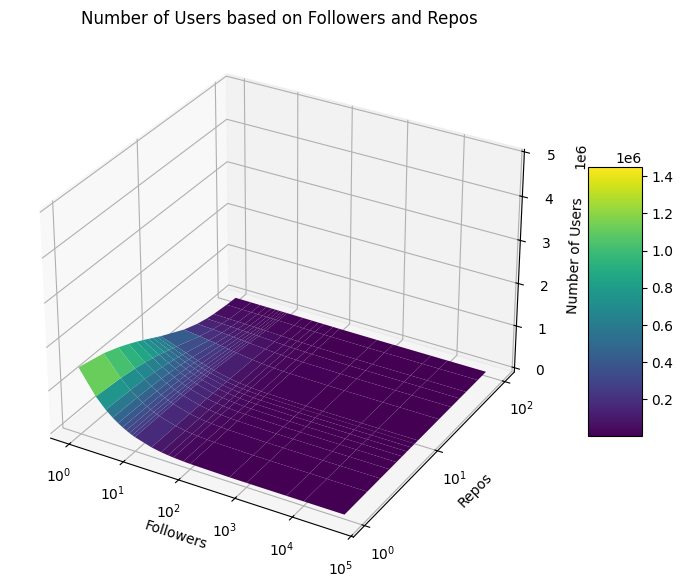

In [22]:
# another graph, same as previous graph, but keep the same z scale as picture 1
# this will have a runtime error, but it's all good

# create a grid
follower_thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 75, 100, 500, 1000, 5000, 10000, 50000]
repo_thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 75, 100]
number_of_users_grid = np.zeros((len(follower_thresholds), len(repo_thresholds)))
for i, followers in enumerate(follower_thresholds):
    for j, repos in enumerate(repo_thresholds):
        number_of_users_grid[i, j] = calculate_number_of_users(followers, repos)
followers_grid, repos_grid = np.meshgrid(follower_thresholds, repo_thresholds)
number_of_users_grid = number_of_users_grid.T


# print the 3d graph
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
# important: this step is also crutial
log_followers_grid = np.log10(followers_grid)
log_repos_grid = np.log10(repos_grid)
surf = ax.plot_surface(log_followers_grid, log_repos_grid, number_of_users_grid, cmap='viridis')


# Labels and title
ax.set_xlabel('Followers')
ax.set_ylabel('Repos')
ax.set_zlabel('Number of Users')
ax.set_title('Number of Users based on Followers and Repos')

# Add color bar to show the scale of number of users
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.savefig("Database/ThesisPictures/GithubGatherData_SelectThreshold_followerXrepoAfter.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [23]:
# number of users with 0 repos and 0 followers
number_of_users_grid[0, 0]

np.float64(4951278.0)

In [24]:
# number of users with 1+ repos and 1+ followers
number_of_users_grid[1, 1]

np.float64(1450924.0)